In [ ]:
import numpy as np

arr = np.arange(1, 26).reshape(5, 5)
print(arr)

[[ 1  2  3  4  5]
 [ 6  7  8  9 10]
 [11 12 13 14 15]
 [16 17 18 19 20]
 [21 22 23 24 25]]


In [ ]:
third_row = arr[2]
print(third_row)

[11 12 13 14 15]


In [ ]:
last_column = arr[:, -1]
print(last_column)

[ 5 10 15 20 25]


In [ ]:
arr[arr % 2 == 0] = 0
print(arr)

[[ 1  0  3  0  5]
 [ 0  7  0  9  0]
 [11  0 13  0 15]
 [ 0 17  0 19  0]
 [21  0 23  0 25]]


In [ ]:
row_sum = arr.sum(axis=1)
print(row_sum)

[ 9 16 39 36 69]


In [ ]:
col_sum = arr.sum(axis=0)
print(col_sum)

[33 24 39 28 45]


In [ ]:
arr[2, 3]

np.int64(0)

In [ ]:
arr[arr > 10]

array([11, 13, 15, 17, 19, 21, 23, 25])

In [ ]:
arr + 5

array([[ 6,  5,  8,  5, 10],
       [ 5, 12,  5, 14,  5],
       [16,  5, 18,  5, 20],
       [ 5, 22,  5, 24,  5],
       [26,  5, 28,  5, 30]])

Broadcasting allows NumPy to perform arithmetic operations on arrays of different shapes by automatically expanding the smaller array across the larger one — without actually copying data.

In [ ]:
import numpy as np

a = np.array([[1,2,3],
              [4,5,6]])

b = np.array([10,20,30])

In [ ]:
result = a + b
print(result)

[[11 22 33]
 [14 25 36]]


Why Broadcasting Works (Step-by-step)

Step 1: Compare shapes from right to left
a → (2, 3)
b →     (3,)
NumPy treats b as:
(1, 3)

Rule:
Two dimensions are compatible if:

They are equal
OR

One of them is 1

Here:

3 == 3 ✔

2 and 1 → compatible ✔

So NumPy stretches b vertically:
[[10,20,30],
 [10,20,30]]
 Now addition is element-wise:
 [[1+10, 2+20, 3+30],
 [4+10, 5+20, 6+30]]

Output Shape?

The result takes the maximum size in each dimension.

So shape = (2,3)

Because:

Rows → max(2,1) = 2

Columns → max(3,3) = 3

In [ ]:
b = np.array([10,20])

Mathematical Explanation of Failure

For broadcasting:

For every dimension (from right):
dimension_a == dimension_b
OR
dimension_a == 1
OR
dimension_b == 1

3 ≠ 2
3 ≠ 1
2 ≠ 1

Vectorization vs Loop
For 1 million inputs:

Loop time ≈ 0.39 seconds

Vectorized time ≈ 0.016 seconds

Vectorization is roughly 20–25x faster.

Python For-Loop Version

What it does:

Goes element by element

Executes Python bytecode each time

Appends to a list

Very slow for large data

Python loops run in the Python interpreter — which is not optimized for heavy numerical computation.

In [ ]:
import numpy as np
import time

# Function using Python loop
def f_loop(x):
    result = []
    for value in x:                 # Iterate element-by-element
        result.append(value**2 + 3*value + 2)
    return result

In [ ]:
# Function using NumPy vectorization
def f_vectorized(x):
    return x**2 + 3*x + 2           # Element-wise operation on entire array

In [ ]:
# Generate 1 million random values
x = np.random.rand(1_000_000)

# Measure loop execution time
start = time.time()
loop_result = f_loop(x)
loop_time = time.time() - start

# Measure vectorized execution time
start = time.time()
vector_result = f_vectorized(x)
vector_time = time.time() - start

print("Loop execution time:", loop_time)
print("Vectorized execution time:", vector_time)

Loop execution time: 0.4230530261993408
Vectorized execution time: 0.015865802764892578


Why Vectorization is Computationally Efficient

NumPy operations run in optimized C (not Python).

Avoids Python loop overhead for every element.

Uses contiguous memory → better CPU cache performance.

Enables SIMD (parallel CPU operations).

Reduces dynamic type checking done in Python loops.

Determinant

Determinant ≈ 5

Since determinant ≠ 0:

Matrix is invertible

Transformation does NOT collapse space

Area scaling factor = 5

Meaning: Any 2D area transformed by A gets scaled by 5.

Inverse Verification
A * A_inv ≈ Identity matrix
The tiny value -1.11e-16 is just floating-point rounding error. It is effectively 0.

So inverse is correct.

Interpretation:
Inverse matrix “undoes” the transformation of A.

In [ ]:
import numpy as np

# Define matrix
A = np.array([[2, 1],
              [1, 3]])

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(A)

print("Eigenvalues:")
print(eigenvalues)

print("\nEigenvectors (each column corresponds to an eigenvalue):")
print(eigenvectors)

Eigenvalues:
[1.38196601 3.61803399]

Eigenvectors (each column corresponds to an eigenvalue):
[[-0.85065081 -0.52573111]
 [ 0.52573111 -0.85065081]]


Compute Eigenvalues and Eigenvectors
Eigenvalues:  [1.38196601 3.61803399]
Eigenvectors:  [[-0.85065081 -0.52573111]
 [ 0.52573111 -0.85065081]]

Geometric Meaning (Clear Explanation)

Think of matrix A as a transformation of space.

Normally when you multiply a vector by A:

Direction changes

Length changes

But eigenvectors are special directions:

Their direction does NOT change

They only get scaled

Mathematically:
A v = λ v
Where:

v = eigenvector (direction preserved)

λ = eigenvalue (scaling factor)

Visual Interpretation

If:

λ > 1 → stretch

0 < λ < 1 → shrink

λ < 0 → flip direction + scale

λ = 0 → collapse to zero

Here:
Both eigenvalues > 1 → pure stretching along two perpendicular directions.

Q5. Probability & Sampling Generate 10,000 samples from a normal distribution (mean=5, std=2). (a) Plot histogram.

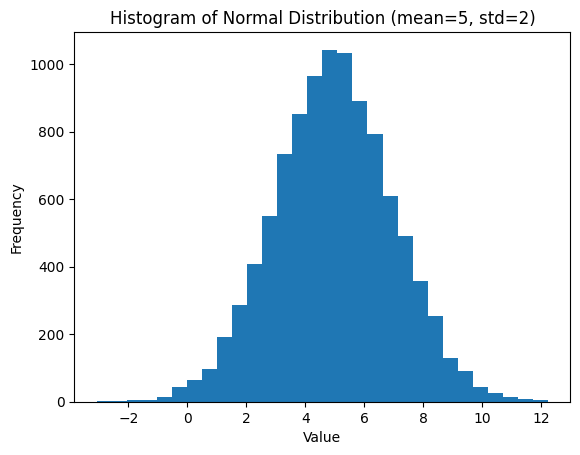

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate 10,000 samples
# loc = mean
# scale = standard deviation
# size = number of samples
samples = np.random.normal(loc=5, scale=2, size=10000)

# Plot histogram
plt.hist(samples, bins=30)
plt.title("Histogram of Normal Distribution (mean=5, std=2)")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.show()

(b) Sample Mean & Variance

Population mean = 5

Population variance = 2² = 4

Your computed sample mean will be close to 5
Your sample variance will be close to 4

But not exactly equal.

That difference is normal.

(c) Why Sample Mean ≠ Population Mean?

Because of sampling variability.

You are not observing the entire population.
You only took 10,000 random points.

Each time you generate samples, you’ll get slightly different values.

This difference is called:

Sampling Error

Even if distribution is perfect normal,
finite samples fluctuate randomly.

(d) What Happens If Sample Size Increases?

As sample size increases:

Sampling error decreases

Sample mean gets closer to true mean

Variance estimate becomes more stable

Distribution of sample mean becomes tighter

This is explained by:

Law of Large Numbers

If n → infinity
Sample mean → population mean

SECTION B — Pandas (Data Handling & Feature Engineering)

In [ ]:
import pandas as pd

# Create dataset
data = {
    "Name": ["A","B","C","D","E","F"],
    "Age": [23,25,29,22,24,30],
    "Salary": [50000,60000,80000,45000,52000,90000],
    "Department": ["IT","HR","IT","HR","IT","Finance"]
}

df = pd.DataFrame(data)

print(df)

  Name  Age  Salary Department
0    A   23   50000         IT
1    B   25   60000         HR
2    C   29   80000         IT
3    D   22   45000         HR
4    E   24   52000         IT
5    F   30   90000    Finance


Filter employees from IT department

In [ ]:
# Filter rows where Department == "IT"
it_employees = df[df["Department"] == "IT"]

print(it_employees)

  Name  Age  Salary Department
0    A   23   50000         IT
2    C   29   80000         IT
4    E   24   52000         IT


Compute average salary per department using groupby

In [ ]:
# Group by Department and calculate mean salary
avg_salary = df.groupby("Department")["Salary"].mean()

print(avg_salary)

Department
Finance    90000.000000
HR         52500.000000
IT         60666.666667
Name: Salary, dtype: float64


Add new column: Salary_After_Raise (10% increment)

In [ ]:
# Add 10% increment
df["Salary_After_Raise"] = df["Salary"] * 1.10

print(df)

  Name  Age  Salary Department  Salary_After_Raise
0    A   23   50000         IT             55000.0
1    B   25   60000         HR             66000.0
2    C   29   80000         IT             88000.0
3    D   22   45000         HR             49500.0
4    E   24   52000         IT             57200.0
5    F   30   90000    Finance             99000.0


Sort dataframe by Salary (descending)

In [ ]:
# Sort by Salary in descending order
sorted_df = df.sort_values(by="Salary", ascending=False)

print(sorted_df)

  Name  Age  Salary Department  Salary_After_Raise
5    F   30   90000    Finance             99000.0
2    C   29   80000         IT             88000.0
1    B   25   60000         HR             66000.0
4    E   24   52000         IT             57200.0
0    A   23   50000         IT             55000.0
3    D   22   45000         HR             49500.0


Difference between loc and iloc

This is important conceptually.

 * loc

Label-based indexing

Uses column names and row labels

In [ ]:
df.loc[0, "Salary"]

np.int64(50000)

Meaning:
Row label 0, column "Salary"

 * iloc

Position-based indexing

Uses integer positions

Example:

In [ ]:
df.iloc[0, 2]

np.int64(50000)

In [ ]:
df.loc[0:2]   # Includes row 2
df.iloc[0:2]  # Excludes row 2

,Name,Age,Salary,Department,Salary_After_Raise
0,A,23,50000,IT,55000.0
1,B,25,60000,HR,66000.0


In [30]:
import pandas as pd
import numpy as np

# Create DataFrame
data = {
    "Name": ["A","B","C","D","E","F"],
    "Age": [23,25,29,22,24,30],
    "Salary": [50000,60000,80000,45000,52000,90000],
    "Department": ["IT","HR","IT","HR","IT","Finance"]
}

df = pd.DataFrame(data)

print("Original DataFrame:")
print(df)

Original DataFrame:
  Name  Age  Salary Department
0    A   23   50000         IT
1    B   25   60000         HR
2    C   29   80000         IT
3    D   22   45000         HR
4    E   24   52000         IT
5    F   30   90000    Finance


(a) Introduce at least two missing values in Age column

In [31]:
# Introduce missing values (NaN)
df.loc[1, "Age"] = np.nan
df.loc[4, "Age"] = np.nan

print("\nDataFrame after introducing missing values:")
print(df)


DataFrame after introducing missing values:
  Name   Age  Salary Department
0    A  23.0   50000         IT
1    B   NaN   60000         HR
2    C  29.0   80000         IT
3    D  22.0   45000         HR
4    E   NaN   52000         IT
5    F  30.0   90000    Finance


(b) Detect missing values

In [32]:
# Detect missing values (returns True where NaN exists)
print("\nMissing values (True indicates missing):")
print(df.isnull())

# Count total missing values per column
print("\nCount of missing values per column:")
print(df.isnull().sum())


Missing values (True indicates missing):
    Name    Age  Salary  Department
0  False  False   False       False
1  False   True   False       False
2  False  False   False       False
3  False  False   False       False
4  False   True   False       False
5  False  False   False       False

Count of missing values per column:
Name          0
Age           2
Salary        0
Department    0
dtype: int64


Explanation:

isnull() → identifies missing values

sum() → counts them

(c) Fill missing values using median

In [33]:
# Compute median of Age column
median_age = df["Age"].median()

# Fill missing values with median
df["Age"] = df["Age"].fillna(median_age)

print("\nDataFrame after filling missing values with median:")
print(df)


DataFrame after filling missing values with median:
  Name   Age  Salary Department
0    A  23.0   50000         IT
1    B  26.0   60000         HR
2    C  29.0   80000         IT
3    D  22.0   45000         HR
4    E  26.0   52000         IT
5    F  30.0   90000    Finance


Explanation:

Median is calculated from non-missing values

fillna() replaces NaN values

(d) When is median preferred over mean?

Median is preferred when:

Data contains outliers

Distribution is skewed

You want a robust central value

Example:
If ages were [22, 23, 24, 25, 100]

Mean = heavily affected by 100

Median = stable

Median is resistant to extreme values.

(e) Drop rows with missing values and compare dataset size

In [34]:
# Reintroduce missing values
df.loc[1, "Age"] = np.nan
df.loc[4, "Age"] = np.nan

print("\nDataset size before dropping:", df.shape)

# Drop rows with any missing values
df_dropped = df.dropna()

print("Dataset size after dropping:", df_dropped.shape)

print("\nDataFrame after dropping missing rows:")
print(df_dropped)


Dataset size before dropping: (6, 4)
Dataset size after dropping: (4, 4)

DataFrame after dropping missing rows:
  Name   Age  Salary Department
0    A  23.0   50000         IT
2    C  29.0   80000         IT
3    D  22.0   45000         HR
5    F  30.0   90000    Finance


Explanation:

dropna() removes rows containing NaN

Compare .shape before and after

You lose data → which may reduce model performance

In [35]:
import pandas as pd

data = {
    "Name": ["A","B","C","D","E","F"],
    "Age": [23,25,29,22,24,30],
    "Salary": [50000,60000,80000,45000,52000,90000],
    "Department": ["IT","HR","IT","HR","IT","Finance"]
}

df = pd.DataFrame(data)

print(df)

  Name  Age  Salary Department
0    A   23   50000         IT
1    B   25   60000         HR
2    C   29   80000         IT
3    D   22   45000         HR
4    E   24   52000         IT
5    F   30   90000    Finance


Highest paid employee per department

In [36]:
# Get index of highest salary per department
idx = df.groupby("Department")["Salary"].idxmax()

# Select those rows
highest_paid = df.loc[idx]

print("Highest paid employee per department:")
print(highest_paid)

Highest paid employee per department:
  Name  Age  Salary Department
5    F   30   90000    Finance
1    B   25   60000         HR
2    C   29   80000         IT


Explanation:

groupby("Department")

idxmax() finds row index of maximum salary per group

loc selects full row details

(b) Count employees per department

In [37]:
# Count number of employees in each department
employee_count = df.groupby("Department")["Name"].count()

print("Employee count per department:")
print(employee_count)

Employee count per department:
Department
Finance    1
HR         2
IT         3
Name: Name, dtype: int64


In [38]:
df["Department"].value_counts()

,count
Department,
IT,3
HR,2
Finance,1


(c) Sort departments by average salary

In [39]:
# Calculate average salary per department
avg_salary = df.groupby("Department")["Salary"].mean()

# Sort in descending order
sorted_departments = avg_salary.sort_values(ascending=False)

print("Departments sorted by average salary:")
print(sorted_departments)

Departments sorted by average salary:
Department
Finance    90000.000000
IT         60666.666667
HR         52500.000000
Name: Salary, dtype: float64


(d) Pivot table showing average salary per department

In [40]:
# Create pivot table
pivot_table = pd.pivot_table(
    df,
    values="Salary",
    index="Department",
    aggfunc="mean"
)

print("Pivot table (Average Salary per Department):")
print(pivot_table)

Pivot table (Average Salary per Department):
                  Salary
Department              
Finance     90000.000000
HR          52500.000000
IT          60666.666667


In [41]:
import pandas as pd

# Original DataFrame
data = {
    "Name": ["A","B","C","D","E","F"],
    "Age": [23,25,29,22,24,30],
    "Salary": [50000,60000,80000,45000,52000,90000],
    "Department": ["IT","HR","IT","HR","IT","Finance"]
}

df = pd.DataFrame(data)

print("Employee DataFrame:")
print(df)

Employee DataFrame:
  Name  Age  Salary Department
0    A   23   50000         IT
1    B   25   60000         HR
2    C   29   80000         IT
3    D   22   45000         HR
4    E   24   52000         IT
5    F   30   90000    Finance


In [42]:
# Second DataFrame
bonus_data = {
    "Name": ["A","C","E","G"],   # G does not exist in original df
    "Bonus": [5000, 8000, 6000, 7000]
}

df_bonus = pd.DataFrame(bonus_data)

print("\nBonus DataFrame:")
print(df_bonus)


Bonus DataFrame:
  Name  Bonus
0    A   5000
1    C   8000
2    E   6000
3    G   7000


(a) Inner Merge

In [43]:
# Inner merge keeps only matching rows
inner_merged = pd.merge(df, df_bonus, on="Name", how="inner")

print("\nInner Merge Result:")
print(inner_merged)


Inner Merge Result:
  Name  Age  Salary Department  Bonus
0    A   23   50000         IT   5000
1    C   29   80000         IT   8000
2    E   24   52000         IT   6000


(b) Left Merge

In [44]:
# Left merge keeps all rows from left dataframe (df)
left_merged = pd.merge(df, df_bonus, on="Name", how="left")

print("\nLeft Merge Result:")
print(left_merged)


Left Merge Result:
  Name  Age  Salary Department   Bonus
0    A   23   50000         IT  5000.0
1    B   25   60000         HR     NaN
2    C   29   80000         IT  8000.0
3    D   22   45000         HR     NaN
4    E   24   52000         IT  6000.0
5    F   30   90000    Finance     NaN


(c) Default Merge Type in Pandas

In [45]:
how="inner"

In [46]:
pd.merge(df, df_bonus, on="Name")

,Name,Age,Salary,Department,Bonus
0,A,23,50000,IT,5000
1,C,29,80000,IT,8000
2,E,24,52000,IT,6000


(d) What Happens to Unmatched Rows?

Depends on merge type:

Inner Merge:

Unmatched rows from both sides are removed.

Left Merge:

All left rows kept.

Unmatched right values become NaN.

Right Merge:

All right rows kept.

Unmatched left values become NaN.

Outer Merge:

All rows from both sides kept.

Missing matches filled with NaN.

In [47]:
import pandas as pd
import numpy as np

data = {
    "Name": ["A","B","C","D","E","F"],
    "Age": [23,25,29,22,24,30],
    "Salary": [50000,60000,80000,45000,52000,90000],
    "Department": ["IT","HR","IT","HR","IT","Finance"]
}

df = pd.DataFrame(data)

print("Original DataFrame:")
print(df)

Original DataFrame:
  Name  Age  Salary Department
0    A   23   50000         IT
1    B   25   60000         HR
2    C   29   80000         IT
3    D   22   45000         HR
4    E   24   52000         IT
5    F   30   90000    Finance


(a) Create Salary_to_Age Ratio Feature

In [48]:
# Create new feature: Salary divided by Age
df["Salary_to_Age"] = df["Salary"] / df["Age"]

print("\nSalary_to_Age feature added:")
print(df)


Salary_to_Age feature added:
  Name  Age  Salary Department  Salary_to_Age
0    A   23   50000         IT    2173.913043
1    B   25   60000         HR    2400.000000
2    C   29   80000         IT    2758.620690
3    D   22   45000         HR    2045.454545
4    E   24   52000         IT    2166.666667
5    F   30   90000    Finance    3000.000000


(b) Create Binary Feature High_Earner (Salary > 60000)

In [49]:
# Create binary feature (1 if Salary > 60000 else 0)
df["High_Earner"] = (df["Salary"] > 60000).astype(int)

print("\nHigh_Earner feature added:")
print(df)


High_Earner feature added:
  Name  Age  Salary Department  Salary_to_Age  High_Earner
0    A   23   50000         IT    2173.913043            0
1    B   25   60000         HR    2400.000000            0
2    C   29   80000         IT    2758.620690            1
3    D   22   45000         HR    2045.454545            0
4    E   24   52000         IT    2166.666667            0
5    F   30   90000    Finance    3000.000000            1


(c) Standardize Salary Column

In [50]:
# Standardize Salary column
mean_salary = df["Salary"].mean()
std_salary = df["Salary"].std()

df["Salary_Standardized"] = (df["Salary"] - mean_salary) / std_salary

print("\nSalary Standardized:")
print(df)


Salary Standardized:
  Name  Age  Salary Department  Salary_to_Age  High_Earner  \
0    A   23   50000         IT    2173.913043            0   
1    B   25   60000         HR    2400.000000            0   
2    C   29   80000         IT    2758.620690            1   
3    D   22   45000         HR    2045.454545            0   
4    E   24   52000         IT    2166.666667            0   
5    F   30   90000    Finance    3000.000000            1   

   Salary_Standardized  
0            -0.708422  
1            -0.156405  
2             0.947630  
3            -0.984431  
4            -0.598019  
5             1.499647  


(d) Why Feature Engineering & Scaling Improve Model Performance
1️ Feature Engineering

Raw features often don’t capture useful patterns.

Example:

Salary alone doesn’t consider age.

Salary_to_Age provides richer signal.

Better features → better learning.

Models can only learn from what you give them.

2️ Feature Scaling

Scaling helps because:

Gradient descent converges faster.

Prevents features with large values dominating others.

Essential for distance-based models (KNN, KMeans).

Required for SVM and Logistic Regression stability.

Without scaling:
Model training becomes unstable or slow.

SECTION C — Data Science Theory

Bias vs Variance (Real-World Example)

Imagine you're predicting house prices.

 Bias

Bias = Error due to wrong assumptions in the model.

Example:
You assume house price depends only on size.

But real prices depend on:

Location

Age

Amenities

Market conditions

Your model is too simple → consistently wrong.

That systematic error = High Bias.

Variance

Variance = Error due to model being too sensitive to training data.

Example:
You build a very complex model that memorizes:

Exact training house prices

Noise

Outliers

On new houses, predictions become unstable.

That instability = High Variance.

(a) What happens when Bias is High?

Model underfits

Performs poorly on training data

Performs poorly on test data

Too simple to capture pattern

Example:
Fitting a straight line to data that is clearly curved.

Symptoms:

High training error

High test error

(b) What happens when Variance is High?

Model overfits

Performs very well on training data

Performs poorly on test data

Memorizes noise

Symptoms:

Low training error

High test error

(c) How Model Complexity Affects Them

As model complexity increases:

Complexity      	Bias	        Variance
Very Simple	      High	         Low
Moderate         	Balanced	       Balanced
Very Complex      	Low	          High

So:

Increase complexity → Bias ↓, Variance ↑

Decrease complexity → Bias ↑, Variance ↓

This trade-off is called:

Bias-Variance Tradeoff

Q12. Train-Test Split

(a) Why Do We Split Dataset?

We split data into:

Training set → Model learns patterns

Test set → Model is evaluated on unseen data

Why?

Because performance on training data is meaningless.

If you test on same data you trained on:

You measure memory

Not generalization

The goal of ML is not to memorize.
It’s to predict unseen data.

(b) What is Overfitting?

Overfitting happens when:

Model learns training data too well

Including noise and outliers

Performs poorly on new data

Example:
Training accuracy = 99%
Test accuracy = 70%

Model memorized training data instead of learning general patterns.

Overfitting = High Variance problem.

(c) sklearn Code for Train-Test Split

In [51]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Example dataset
X = pd.DataFrame({
    "Feature1": [1,2,3,4,5,6,7,8],
    "Feature2": [10,20,30,40,50,60,70,80]
})

y = [0,1,0,1,0,1,0,1]  # Target variable

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,     # 20% for testing
    random_state=42    # For reproducibility
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 6
Testing size: 2


(d) What is Cross-Validation?

Train-test split gives one evaluation.

But what if the split was unlucky?

Cross-validation solves this.

Example: 5-fold Cross Validation

Data divided into 5 parts

Model trains on 4 parts

Tests on remaining 1

Repeats 5 times

Average performance is calculated

Benefits:

More reliable estimate

Reduces variance in evaluation

Better model selection

Q13. Correlation vs Causation

(a) Define Both with Examples
 Correlation

Correlation means:
Two variables move together.

Example:
Ice cream sales ↑
Drowning incidents ↑

They are correlated.

But ice cream does NOT cause drowning.

Hidden factor:
Summer heat.

Causation

Causation means:
One variable directly causes change in another.

Example:
Smoking → increases lung cancer risk.

Here, scientific mechanism exists.
That’s causation.

Key Difference

Correlation:

Statistical relationship

No proof of cause

Causation:

Direct cause-effect relationship

Requires experimental or strong evidence

(b) Compute Correlation Matrix in Pandas

In [52]:
import pandas as pd

# Example DataFrame
df = pd.DataFrame({
    "Age": [23,25,29,22,24,30],
    "Salary": [50000,60000,80000,45000,52000,90000]
})

# Compute correlation matrix
correlation_matrix = df.corr()

print(correlation_matrix)

             Age    Salary
Age     1.000000  0.993977
Salary  0.993977  1.000000


(c) How Correlation Helps in Feature Selection

Identify highly correlated features with target.
→ Strong predictive signal.

Detect multicollinearity:
If two features are highly correlated with each other,
keep one and remove the other.

Why?

Because redundant features:

Increase variance

Make models unstable (especially linear regression)

But important:

High correlation ≠ causation.
And low correlation doesn’t mean useless (nonlinear models may still benefit).

Q14. Outlier Detection
(a) IQR Formula

Interquartile Range:

𝐼𝑄𝑅=𝑄3−𝑄1


Outlier boundaries:

𝐿ower = Q1-1.5 x IQR

Upper=Q3+1.5×IQR

Any value outside this range is an outlier.

(b) Python Code to Detect Outliers

In [53]:
import pandas as pd
import numpy as np

# Example DataFrame
df = pd.DataFrame({
    "Salary": [50000,60000,80000,45000,52000,90000,200000]
})

# Calculate Q1 and Q3
Q1 = df["Salary"].quantile(0.25)
Q3 = df["Salary"].quantile(0.75)

IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Detect outliers
outliers = df[(df["Salary"] < lower_bound) | (df["Salary"] > upper_bound)]

print("Outliers:")
print(outliers)

Outliers:
   Salary
6  200000


(c) When Should Outliers NOT Be Removed?

This is where people make mistakes.

Do NOT remove outliers when:

They represent valid rare events
(Fraud detection, medical anomalies)

They carry business value
(High-paying customers)

Small dataset
Removing them reduces data too much

Distribution is naturally skewed
(Income data is usually right-skewed)

Removing blindly can:

Destroy signal

Introduce bias

Q15. Evaluation Metrics
(a) Accuracy
Definition:

Proportion of correct predictions out of total predictions.

Formula:

Accuracy=
TP+TN+FP+FN
--------------
TP+TN
	​

Meaning:

How often the model is correct overall.

(b) Precision
Definition:

Out of all predicted positives, how many were actually positive?

Formula:

Precision=
TP+FP
----------
TP
	​

Meaning:

When model says “Positive”, how often is it right?

Important when:
False positives are costly.

Example:
Spam detection — you don’t want important emails marked as spam.

(c) Recall (Sensitivity)
Definition:

Out of all actual positives, how many did we correctly identify?

Formula:

Recall=
TP+FN
----------
TP
	​

Meaning:

How many real positives did we capture?

Important when:
Missing positives is costly.

Example:
Cancer detection — missing a cancer case is dangerous.

(d) F1 Score
Definition:

Harmonic mean of Precision and Recall.

Formula:
          2 x Precision x Recall
 F1 =   ------------------------
            Precision + Recall

Precision+Recall
Precision×Recall
	​


Or directly:


        2TP
 F1=  -------
      2TP+FP+FN
	​

Why harmonic mean?

It penalizes extreme imbalance between precision and recall.

If one is very low → F1 becomes low.

(e) When is Accuracy Misleading?

Accuracy is misleading when dataset is imbalanced.

Example:

Fraud detection:

1000 transactions

990 normal

10 fraud

Model predicts:
“Everything is normal”

Accuracy:

990
-----  = 99%
1000

	​



Looks excellent.

But:
Recall for fraud = 0%

Model is useless.

SECTION D — Machine Learning Implementation

(a) Generate Synthetic Regression Dataset

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# For reproducibility
np.random.seed(42)

# Generate 100 random X values between 0 and 2
X = 2 * np.random.rand(100, 1)

# Generate y with linear relationship + noise
y = 4 * X + 3 + np.random.randn(100, 1)

(b) Train LinearRegression Model

In [55]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

(c) Print Coefficients and Intercept

In [56]:
print("Coefficient (slope):", model.coef_[0][0])
print("Intercept:", model.intercept_[0])

Coefficient (slope): 3.7701133864384846
Intercept: 3.2150961575467467


(d) Plot Regression Line

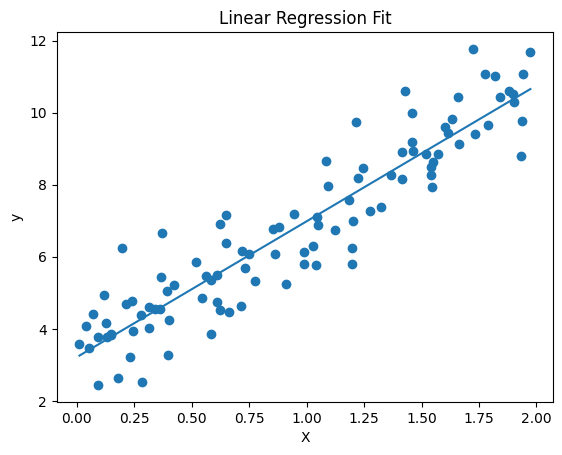

In [57]:
y_pred = model.predict(X)

# Sort values for clean plotting
sorted_idx = X[:, 0].argsort()
X_sorted = X[sorted_idx]
y_sorted = y_pred[sorted_idx]

plt.scatter(X, y)
plt.plot(X_sorted, y_sorted)
plt.xlabel("X")
plt.ylabel("y")
plt.title("Linear Regression Fit")
plt.show()

(e) Interpret Coefficient Meaning

Suppose coefficient ≈ 3.8.

This means:

For every 1 unit increase in X, y increases by about 3.8 units.

In general:

Y=B0 + B1x

β₁ (coefficient) = impact of X on y

β₀ (intercept) = predicted y when X = 0

Q17. Logistic Regression

(a) Generate Binary Classification Dataset

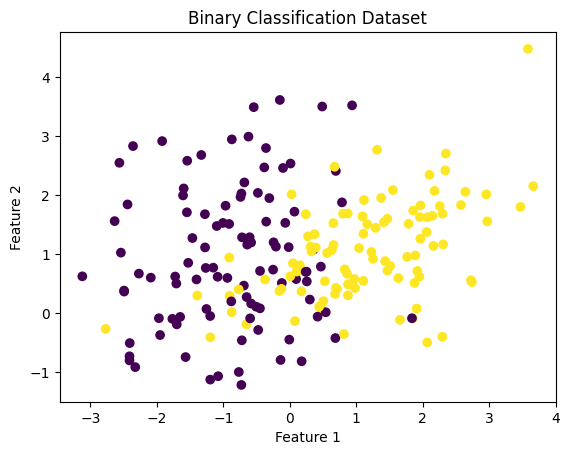

In [58]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

# Generate binary classification dataset
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    n_clusters_per_class=1,
    random_state=42
)

# Visualize data
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.title("Binary Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

(b) Train LogisticRegression Model

In [59]:
# Train logistic regression model
model = LogisticRegression()
model.fit(X, y)

LogisticRegression()

(c) Compute Confusion Matrix

In [60]:
# Predictions
y_pred = model.predict(X)

# Confusion matrix
cm = confusion_matrix(y, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[83 17]
 [15 85]]


(d) Calculate Accuracy, Precision, Recall

In [61]:
acc = accuracy_score(y, y_pred)
prec = precision_score(y, y_pred)
rec = recall_score(y, y_pred)

print("Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

Accuracy: 0.84
Precision: 0.8333333333333334
Recall: 0.85


(e) Interpret Model Output

In [62]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

Coefficients: [[ 1.81773105 -0.40929647]]
Intercept: [0.18734723]


Q18. Decision Tree

(a) Train DecisionTreeClassifier

What happened:

The model learned decision rules like:

IF Feature1 ≤ value
THEN go left
ELSE go right

It recursively splits the dataset to reduce impurity (usually Gini index by default).

Goal:
Create pure leaf nodes (all 0s or all 1s).

(b) Plot Decision Tree

Each node shows:

Splitting condition

Gini impurity

Number of samples

Class distribution

Leaves at bottom give final classification.

Decision trees create rectangular decision boundaries.

(c) Overfitting in Decision Trees

Decision trees are very prone to overfitting because:

They can grow until each leaf has 1 sample.

They can memorize noise.

They create very complex rules.

What happens:

Training accuracy → very high
Test accuracy → drops

Why?

Because the tree learns random fluctuations in training data.

A very deep tree = high variance model.

(d) Hyperparameters to Control Overfitting

At least three important ones:

1️.max_depth

Limits how deep the tree can grow.
Smaller depth → simpler model.

2️ min_samples_split

Minimum number of samples required to split a node.
Higher value → fewer splits.

3️ min_samples_leaf

Minimum samples required at a leaf node.
Prevents tiny leaves.

Q19. Feature Scaling

Feature scaling = transforming features so they are on similar ranges.

(a) StandardScaler
What it does:

Standardization formula:

x = x- u
    -----
    sigma
	​


Where:

μ = mean

σ = standard deviation

After scaling:

Mean ≈ 0

Standard deviation ≈ 1

Interpretation:

It centers data around zero and rescales variance.

When useful:

When data is roughly normally distributed.

(b) MinMaxScaler
What it does:
 x' = x - xmin
      ---------
      xmax- xmin
	​



	​


Transforms values into range:


[0,1]
Interpretation:

Preserves shape of distribution but compresses range.

When useful:

When you need bounded values (e.g., neural networks).

(c) When Scaling Is Necessary

Scaling is necessary when:

Features have different units
Example:

Salary (50,000)

Age (25)

Salary will dominate without scaling.

Model uses distance calculations.

Model uses gradient descent.

Features vary by large magnitude differences.

Scaling is NOT always required.

(d) Which Models Require Scaling?
Require / Strongly Benefit:

Logistic Regression

Linear Regression (with regularization)

SVM

KNN

KMeans

Neural Networks

PCA

Why?
They rely on:

Distance

Dot products

Gradient descent

Q20. End-to-End Pipeline

Step 1: Create Sample Dataset (with missing values)

In [63]:
import pandas as pd
import numpy as np

# Sample dataset
data = {
    "Age": [23, 25, np.nan, 22, 24, 30],
    "Salary": [50000, 60000, 80000, 45000, np.nan, 90000],
    "Department": ["IT", "HR", "IT", "HR", "IT", "Finance"],
    "High_Earner": [0, 0, 1, 0, 0, 1]
}

df = pd.DataFrame(data)

X = df.drop("High_Earner", axis=1)
y = df["High_Earner"]

Step 2: Build Preprocessing + Model Pipeline

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Define column types
numeric_features = ["Age", "Salary"]
categorical_features = ["Department"]

# Numeric pipeline
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # Handle missing values
    ("scaler", StandardScaler())                     # Scale features
])

# Categorical pipeline
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),  # Fill missing categories
    ("encoder", OneHotEncoder(handle_unknown="ignore"))    # One-hot encoding
])

# Combine both pipelines
preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

# Final pipeline
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("model", LogisticRegression())
])

# Train model
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


BONUS QUESTION
==============================

Train Accuracy = 99%
Test Accuracy = 65%

(a) What Problem Is Occurring?

This is classic:

👉 Overfitting

Model learned training data too well,
including noise.

High training performance,
poor generalization.

High variance problem.

(b) Three Possible Solutions

1️ Reduce Model Complexity

Reduce tree depth

Use simpler model

Reduce polynomial degree

2️ Add Regularization

L1 or L2 penalty

Increase regularization strength

3️ Add More Data

More samples reduce variance

Other options:

Drop irrelevant features

Use cross-validation

Use ensemble methods

(c) How to Diagnose Systematically?

Don’t guess. Follow steps:

1️ Check learning curves
Plot training vs validation accuracy as data increases.

2️ Check cross-validation score
If CV score ≈ test score → consistent overfitting.

3️ Analyze feature importance
Is model relying heavily on few features?

4️ Check model complexity
Is tree too deep? Too many parameters?

5️ Check for data leakage
Sometimes 99% training accuracy is leakage.

(d) What Plots Help?

1️ Learning Curve
Training vs Validation accuracy over sample size.

If gap remains large → high variance.

2️ Validation Curve
Performance vs hyperparameter (e.g., depth).

3️ Confusion Matrix
See which class fails.

4️ ROC Curve
Check discrimination ability.

5️ Feature Importance Plot
See if model over-relies on specific features.